# P4. QEC Using Dynamic Circuit

## Repetition code

This part prepares $|0\rangle$ and $|1\rangle$ and goes through the noise models under the 4 circuits described below and checks whether the logical state is preserved.

1. **Bare physical memory**: prepare → storage noise → measure
2. **Encoded, no syndrome**: encode → storage noise → decode → logical measure
3. **Error detection + postselection**: encode → storage noise → syndrome → keep only shots with an all-zero syndrome → decode → logical measure
4. **Dynamic QEC**: encode → first half of storage noise → syndrome → conditional correction → remaining storage noise → decode → logical measure

In [176]:
#SETUP
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit.classical import expr
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError, depolarizing_error, pauli_error

SHOTS = 20_000
CODE_DISTANCE = 11 # choose any odd n >= 3, e.g. 3, 5, 7, or 9
STORAGE_ROUNDS = 12
SEED = 1557


In [177]:
def make_noise_model(
    one_qubit_error=0.001,
    idle_error=0.001,
    two_qubit_error=0.01,
    reset_error=0.01,
    readout_error=0.01,
):
    noise_model = NoiseModel()

    error_1q = depolarizing_error(one_qubit_error, 1)
    error_idle = depolarizing_error(idle_error, 1)
    error_2q = depolarizing_error(two_qubit_error, 2)
    error_reset = pauli_error([('X', reset_error), ('I', 1 - reset_error)])
    error_readout = ReadoutError(
        [
            [1 - readout_error, readout_error],
            [readout_error, 1 - readout_error],
        ]
    )

    # Active single-qubit gate noise is independent of idle/storage noise.
    noise_model.add_all_qubit_quantum_error(
        error_1q,
        ['h', 'x', 'y', 'z', 'sdg'],
    )
    # Each id gate represents one storage round and receives idle_error.
    noise_model.add_all_qubit_quantum_error(error_idle, ['id'])
    noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])
    noise_model.add_all_qubit_quantum_error(error_reset, ['reset'])
    noise_model.add_all_qubit_readout_error(error_readout)
    return noise_model


noise_model = make_noise_model()
simulator = AerSimulator(noise_model=noise_model, seed_simulator=SEED)
noise_model

<NoiseModel on ['measure', 'cx', 'sdg', 'z', 'id', 'reset', 'h', 'x', 'y']>

`idle_error` is **not X-only noise**. A one-qubit depolarizing channel introduces X, Y, and Z Pauli components. In this computational-basis memory experiment, X and Y can change the measured bit, whereas a Z error is invisible to the final Z-basis measurement. The repetition code protects only against the bit-flip component.

For an odd code distance `n`, the circuit uses `n` data qubits and one reusable ancilla. The ancilla is reset between the `n-1` sequential parity measurements, where `s[i] = q[i] xor q[i+1]`. Therefore, each encoded circuit requires only `n+1` qubits. The dynamic decoder chooses the minimum-weight error pattern consistent with the measured syndrome, so an ideal distance-`n` repetition code can correct up to `(n-1)/2` bit flips.

In [178]:
EXPERIMENTS = [
    '1. Bare physical memory',
    '2. Encoded, no syndrome',
    '3. Detection + postselection',
    '4. Dynamic QEC',
]


def validate_code_distance(n):
    if not isinstance(n, int) or isinstance(n, bool) or n < 3 or n % 2 == 0:
        raise ValueError('n must be an odd integer greater than or equal to 3')


def new_registers(n):
    validate_code_distance(n)
    data = QuantumRegister(n, 'data')
    anc = QuantumRegister(1, 'anc')
    syndrome = ClassicalRegister(n - 1, 'syn')
    logical = ClassicalRegister(1, 'logical')
    return data, anc, syndrome, logical


def add_storage(qc, qubits, rounds):
    """Represent `rounds` equal memory steps using noisy identity gates."""
    for _ in range(rounds):
        for qubit in qubits:
            qc.id(qubit)
        qc.barrier(*qubits)


def encode(qc, data):
    """Encode alpha|0> + beta|1> as alpha|0...0> + beta|1...1>."""
    for target in range(1, len(data)):
        qc.cx(data[0], data[target])


def decode(qc, data):
    """Apply the inverse of the fan-out encoding circuit."""
    for target in reversed(range(1, len(data))):
        qc.cx(data[0], data[target])


def extract_syndrome(qc, data, anc, syndrome):
    """Sequentially measure s[i] = q[i] xor q[i+1]."""
    for i in range(len(data) - 1):
        qc.reset(anc[0])
        qc.cx(data[i], anc[0])
        qc.cx(data[i + 1], anc[0])
        qc.measure(anc[0], syndrome[i])
        # Preserve the requested measure-then-next-parity ordering.
        qc.barrier(*data, *anc)


def minimum_weight_correction(n, syndrome_value):
    """Return the minimum-weight bit-error pattern matching a syndrome integer."""
    validate_code_distance(n)
    if not 0 <= syndrome_value < 2 ** (n - 1):
        raise ValueError('syndrome_value does not fit in n-1 bits')

    # Reconstruct the error chain assuming error[0] = 0.
    error = [0] * n
    for i in range(n - 1):
        syndrome_bit = (syndrome_value >> i) & 1
        error[i + 1] = error[i] ^ syndrome_bit

    # The only other pattern with the same syndrome is the bitwise complement.
    if sum(error) > n // 2:
        error = [1 - bit for bit in error]
    return tuple(i for i, bit in enumerate(error) if bit)


def _or_equal_conditions(register, values):
    """Build a balanced classical expression: register equals any value."""
    conditions = [expr.equal(register, value) for value in values]
    while len(conditions) > 1:
        next_level = []
        for i in range(0, len(conditions), 2):
            if i + 1 < len(conditions):
                next_level.append(expr.logic_or(conditions[i], conditions[i + 1]))
            else:
                next_level.append(conditions[i])
        conditions = next_level
    return conditions[0]


def apply_dynamic_correction(qc, data, syndrome):
    """Apply minimum-weight correction for every possible nonzero syndrome."""
    n = len(data)
    syndrome_values_by_qubit = {qubit: [] for qubit in range(n)}
    for syndrome_value in range(1, 2 ** (n - 1)):
        for qubit in minimum_weight_correction(n, syndrome_value):
            syndrome_values_by_qubit[qubit].append(syndrome_value)

    # One conditional X per data qubit; each condition combines its lookup entries.
    for qubit, syndrome_values in syndrome_values_by_qubit.items():
        if syndrome_values:
            condition = _or_equal_conditions(syndrome, syndrome_values)
            with qc.if_test(condition):
                qc.x(data[qubit])


def build_memory_circuit(
    experiment,
    logical_value,
    n=CODE_DISTANCE,
    storage_rounds=STORAGE_ROUNDS,
):
    validate_code_distance(n)
    if logical_value not in (0, 1):
        raise ValueError('logical_value must be 0 or 1')
    if storage_rounds < 0:
        raise ValueError('storage_rounds must be non-negative')

    data, anc, syndrome, logical = new_registers(n)
    qc = QuantumCircuit(data, anc, syndrome, logical, name=experiment)

    if logical_value == 1:
        qc.x(data[0])

    if experiment == EXPERIMENTS[0]:
        add_storage(qc, [data[0]], storage_rounds)

    elif experiment == EXPERIMENTS[1]:
        encode(qc, data)
        add_storage(qc, data, storage_rounds)
        decode(qc, data)

    elif experiment == EXPERIMENTS[2]:
        encode(qc, data)
        add_storage(qc, data, storage_rounds)
        extract_syndrome(qc, data, anc, syndrome)
        decode(qc, data)

    elif experiment == EXPERIMENTS[3]:
        encode(qc, data)
        first_half = storage_rounds // 2
        second_half = storage_rounds - first_half
        add_storage(qc, data, first_half)
        extract_syndrome(qc, data, anc, syndrome)
        apply_dynamic_correction(qc, data, syndrome)
        add_storage(qc, data, second_half)
        decode(qc, data)

    else:
        raise ValueError(f'Unknown experiment: {experiment}')

    qc.measure(data[0], logical[0])
    return qc

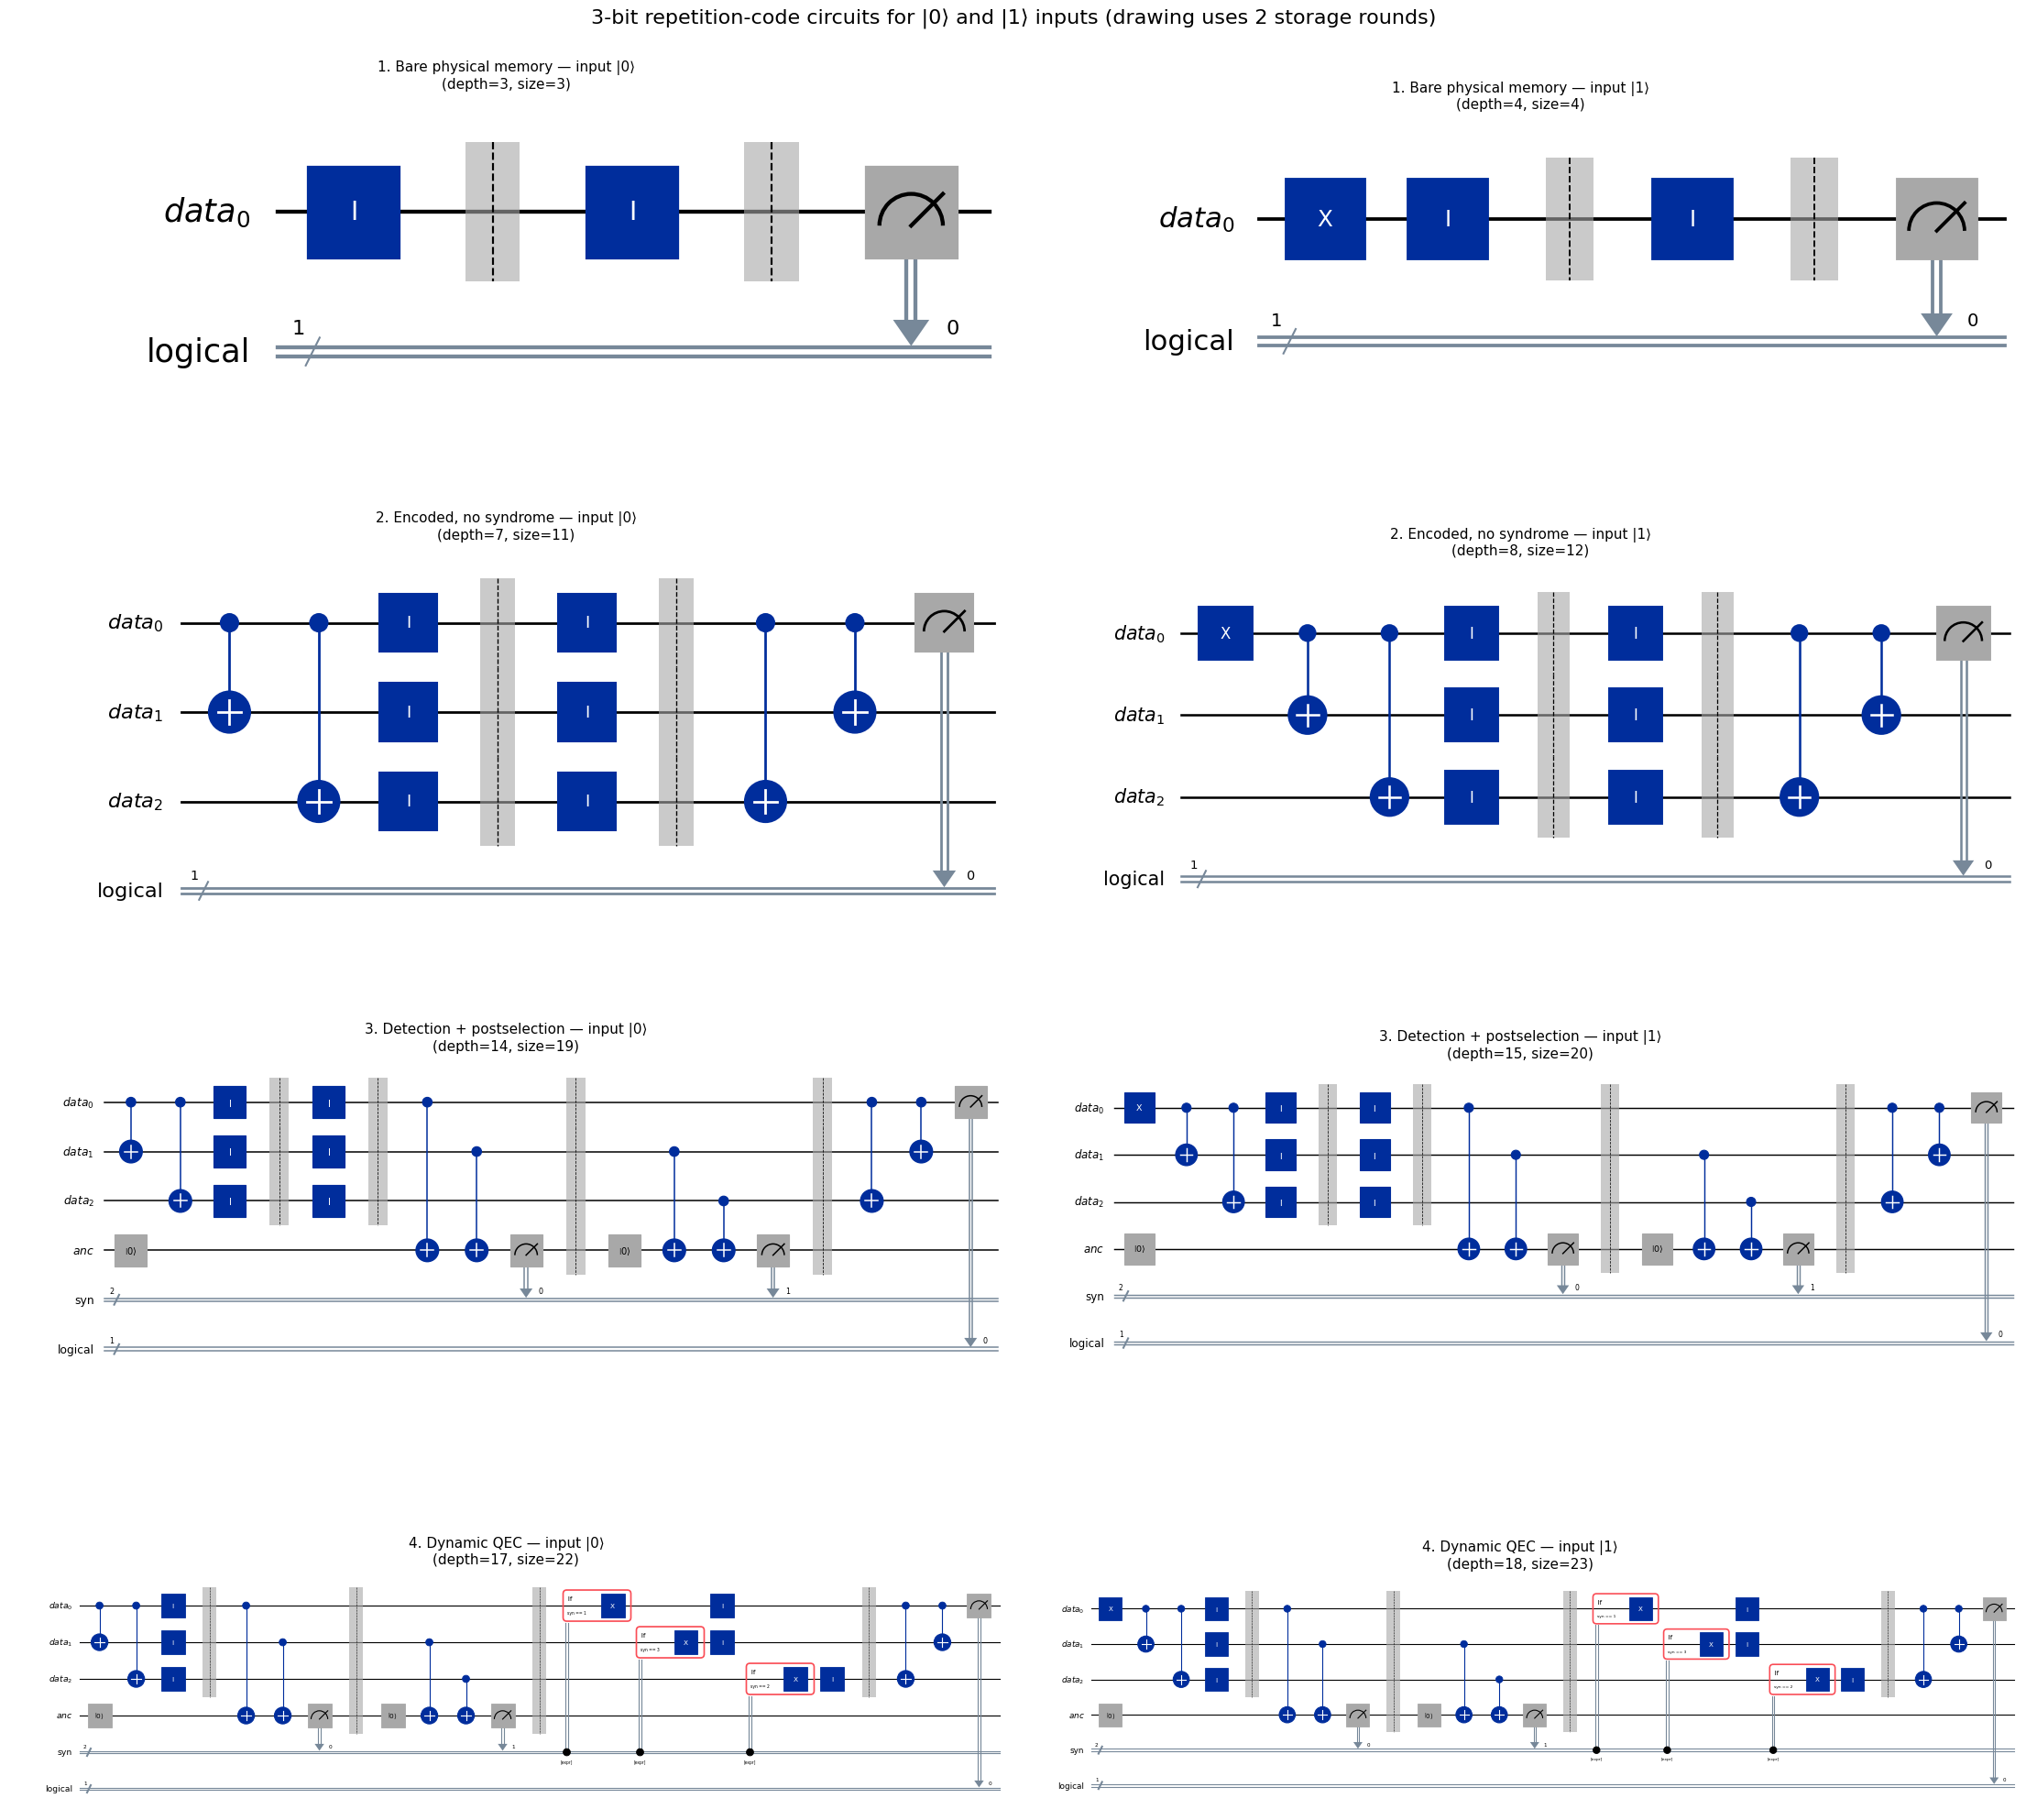

In [179]:
# Draw both logical inputs for all four methods. Fewer storage rounds keep the structure readable.
DRAW_CODE_DISTANCE = 3
DRAW_STORAGE_ROUNDS = min(STORAGE_ROUNDS, 2)
fig_height = max(21, 2.8 * DRAW_CODE_DISTANCE)
fig, axes = plt.subplots(4, 2, figsize=(22, fig_height), constrained_layout=True)

for row, experiment in enumerate(EXPERIMENTS):
    for logical_value in (0, 1):
        ax = axes[row, logical_value]
        circuit = build_memory_circuit(
            experiment,
            logical_value=logical_value,
            n=DRAW_CODE_DISTANCE,
            storage_rounds=DRAW_STORAGE_ROUNDS,
        )
        circuit.draw(
            output='mpl',
            fold=-1,
            idle_wires=False,
            scale=0.55,
            ax=ax,
            expr_len=18,
        )
        ax.set_title(
            f'{experiment} — input |{logical_value}⟩\n'
            f'(depth={circuit.depth()}, size={circuit.size()})',
            fontsize=11,
            pad=10,
        )

fig.suptitle(
    f'{DRAW_CODE_DISTANCE}-bit repetition-code circuits for |0⟩ and |1⟩ inputs '
    f'(drawing uses {DRAW_STORAGE_ROUNDS} storage rounds)',
    fontsize=16,
)
plt.show()

### Run and analyze

The experiment runs `|0⟩` and `|1⟩` with the same number of shots and combines their results. For postselection, the logical error rate uses **only accepted shots** with an all-zero syndrome as its denominator.

**Postselection cost** is the sampling loss caused by discarding rejected shots:

- `acceptance_rate = accepted_shots / total_shots`
- `discard_rate = 1 - acceptance_rate`
- `sampling_overhead = 1 / acceptance_rate`

For example, an 80% acceptance rate means that 20% of the shots are discarded and that approximately 12,500 raw shots are needed to obtain 10,000 accepted shots. The other three methods do not postselect, so their acceptance rate is 100% by definition.

In [180]:
def parse_count_key(key):
    """Return (logical_bit, syndrome_int) from Qiskit count keys."""
    # Registers were added as syn then logical, so counts are printed `logical syn`.
    pieces = key.split()
    if len(pieces) != 2:
        raise ValueError(f'Unexpected count key: {key!r}')
    return int(pieces[0], 2), int(pieces[1], 2)


def run_comparison(
    simulator=simulator,
    n=CODE_DISTANCE,
    shots=SHOTS,
    storage_rounds=STORAGE_ROUNDS,
    seed=SEED,
):
    validate_code_distance(n)
    required_qubits = n + 1  # n data qubits + one reset-and-reused parity ancilla
    capacity = getattr(getattr(simulator, 'target', None), 'num_qubits', None)
    if capacity is not None and required_qubits > capacity:
        raise ValueError(
            f'n={n} requires {required_qubits} qubits, but this simulator supports '
            f'at most {capacity}. Use n <= {capacity - 1} or a larger backend.'
        )
    if n > 9:
        warnings.warn(
            'The exact minimum-weight dynamic decoder grows exponentially with n; '
            'distances above 9 can be slow even when the qubit count fits.',
            RuntimeWarning,
            stacklevel=2,
        )
    circuits = []
    metadata = []
    for experiment in EXPERIMENTS:
        for logical_value in (0, 1):
            circuits.append(
                build_memory_circuit(
                    experiment,
                    logical_value,
                    n=n,
                    storage_rounds=storage_rounds,
                )
            )
            metadata.append((experiment, logical_value))

    compiled = transpile(
        circuits,
        simulator,
        optimization_level=0,
        seed_transpiler=seed,
    )
    result = simulator.run(compiled, shots=shots, seed_simulator=seed).result()

    totals = {
        experiment: {'accepted': 0, 'errors': 0, 'all_shots': 0}
        for experiment in EXPERIMENTS
    }
    raw_counts = {}

    for i, (experiment, expected) in enumerate(metadata):
        counts = result.get_counts(i)
        raw_counts[(experiment, expected)] = counts
        for key, count in counts.items():
            measured, syndrome = parse_count_key(key)
            totals[experiment]['all_shots'] += count

            accept = experiment != EXPERIMENTS[2] or syndrome == 0
            if accept:
                totals[experiment]['accepted'] += count
                totals[experiment]['errors'] += count * (measured != expected)

    rows = []
    for experiment in EXPERIMENTS:
        item = totals[experiment]
        accepted = item['accepted']
        logical_error_rate = item['errors'] / accepted if accepted else np.nan
        stderr = (
            np.sqrt(logical_error_rate * (1 - logical_error_rate) / accepted)
            if accepted else np.nan
        )
        acceptance_rate = accepted / item['all_shots']
        rows.append(
            {
                'experiment': experiment,
                'logical_error_rate': logical_error_rate,
                'standard_error': stderr,
                'acceptance_rate': acceptance_rate,
                'discard_rate': 1 - acceptance_rate,
                'sampling_overhead': 1 / acceptance_rate if acceptance_rate else np.inf,
                'accepted_shots': accepted,
                'total_shots': item['all_shots'],
            }
        )

    table = pd.DataFrame(rows).set_index('experiment')
    return table, raw_counts, compiled


comparison, raw_counts, compiled_circuits = run_comparison()
comparison.style.format(
    {
        'logical_error_rate': '{:.4%}',
        'standard_error': '{:.4%}',
        'acceptance_rate': '{:.2%}',
        'discard_rate': '{:.2%}',
        'sampling_overhead': '{:.3f}×',
        'accepted_shots': '{:,.0f}',
        'total_shots': '{:,.0f}',
    }
)

/var/folders/ns/srwmbl_53fq2h0mc9v695mhr0000gn/T/ipykernel_93410/3370287986.py:99: RuntimeWarning: The exact minimum-weight dynamic decoder grows exponentially with n; distances above 9 can be slow even when the qubit count fits.
  comparison, raw_counts, compiled_circuits = run_comparison()


,logical_error_rate,standard_error,acceptance_rate,discard_rate,sampling_overhead,accepted_shots,total_shots
experiment,,,,,,,
1. Bare physical memory,1.6850%,0.0644%,100.00%,0.00%,1.000×,"40,000","40,000"
"2. Encoded, no syndrome",10.4600%,0.1530%,100.00%,0.00%,1.000×,"40,000","40,000"
3. Detection + postselection,6.2808%,0.1523%,63.45%,36.55%,1.576×,"25,379","40,000"
4. Dynamic QEC,18.1000%,0.1925%,100.00%,0.00%,1.000×,"40,000","40,000"


### Shot histograms

The logical-output histograms separate the prepared `|0⟩` and `|1⟩` inputs. For error detection, only shots accepted by the all-zero-syndrome postselection rule are included in the logical histogram; the title reports the number of used and total raw shots.

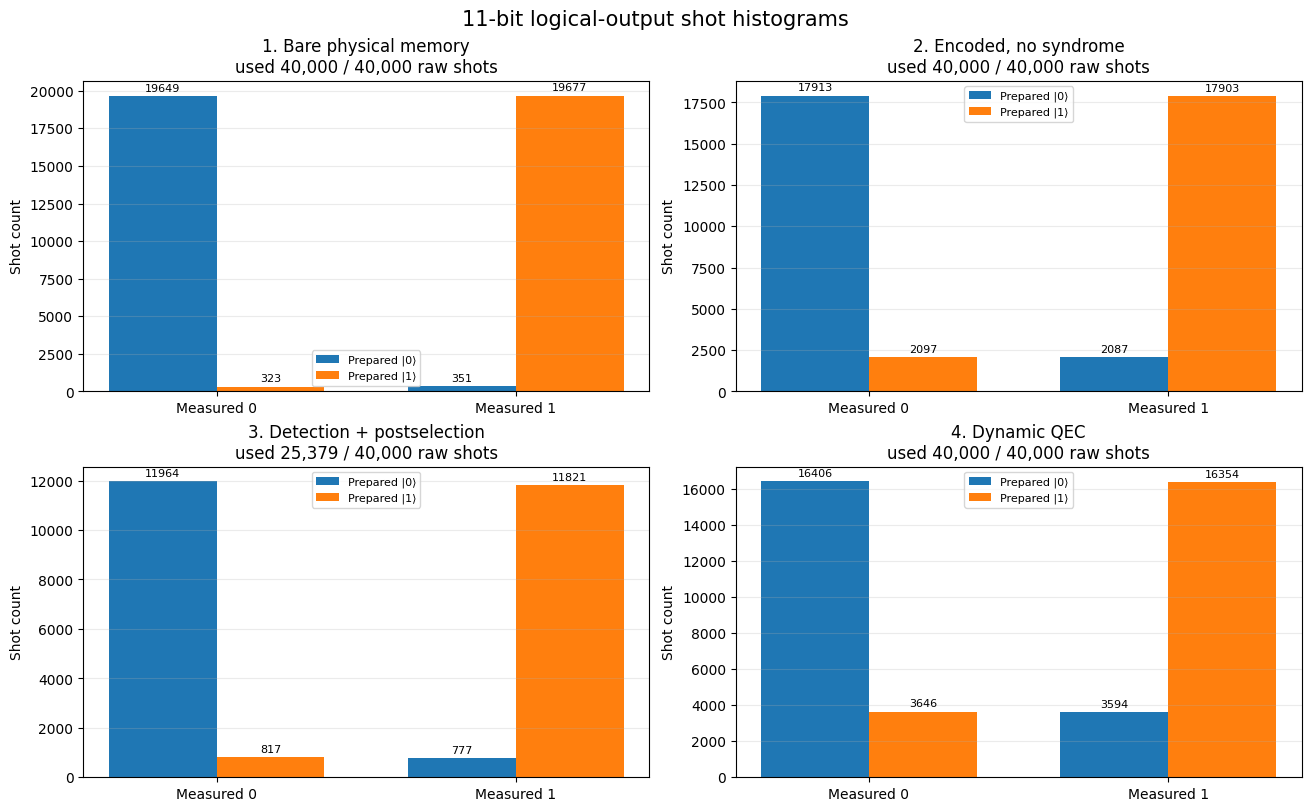

In [181]:
def collect_logical_histograms(raw_counts):
    histograms = {}
    used_shots = {}

    for experiment in EXPERIMENTS:
        histograms[experiment] = {0: {0: 0, 1: 0}, 1: {0: 0, 1: 0}}
        used_shots[experiment] = 0

        for prepared in (0, 1):
            for key, count in raw_counts[(experiment, prepared)].items():
                measured, syndrome = parse_count_key(key)
                if experiment == EXPERIMENTS[2] and syndrome != 0:
                    continue
                histograms[experiment][prepared][measured] += count
                used_shots[experiment] += count

    return histograms, used_shots


logical_histograms, used_shots = collect_logical_histograms(raw_counts)
x = np.arange(2)
width = 0.36
fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)

for ax, experiment in zip(axes.flat, EXPERIMENTS):
    input_zero = [logical_histograms[experiment][0][bit] for bit in (0, 1)]
    input_one = [logical_histograms[experiment][1][bit] for bit in (0, 1)]
    bars_zero = ax.bar(x - width / 2, input_zero, width, label='Prepared |0⟩')
    bars_one = ax.bar(x + width / 2, input_one, width, label='Prepared |1⟩')
    ax.bar_label(bars_zero, padding=2, fontsize=8)
    ax.bar_label(bars_one, padding=2, fontsize=8)
    ax.set_xticks(x, ['Measured 0', 'Measured 1'])
    ax.set_ylabel('Shot count')
    ax.set_title(
        f'{experiment}\nused {used_shots[experiment]:,} / {2 * SHOTS:,} raw shots'
    )
    ax.grid(axis='y', alpha=0.25)
    ax.legend(fontsize=8)

fig.suptitle(f'{CODE_DISTANCE}-bit logical-output shot histograms', fontsize=15)
plt.show()

11-bit repetition-code memory error rates:
  1. Bare physical memory: 1.6850% ± 0.0644%
  2. Encoded, no syndrome: 10.4600% ± 0.1530%
  3. Detection + postselection: 6.2808% ± 0.1523%
  4. Dynamic QEC: 18.1000% ± 0.1925%


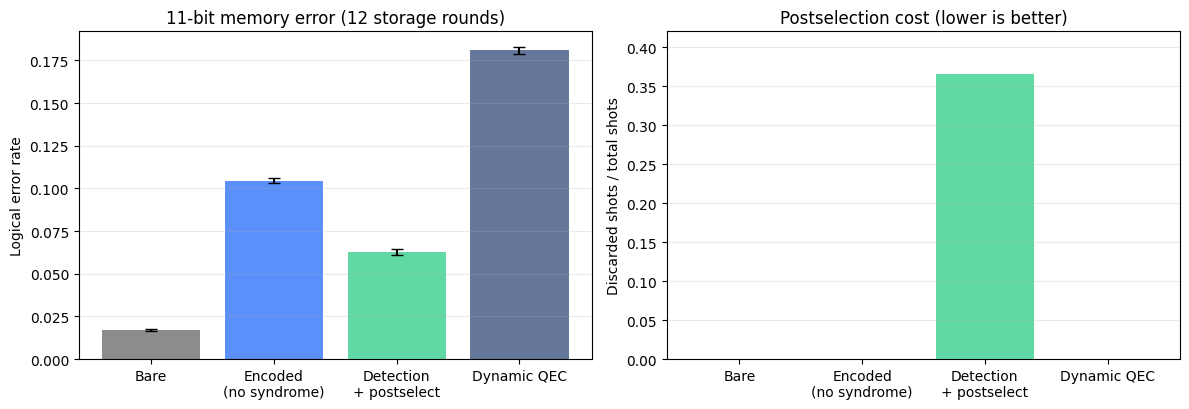

In [182]:
print(f'{CODE_DISTANCE}-bit repetition-code memory error rates:')
for experiment, row in comparison.iterrows():
    print(
        f"  {experiment}: {row['logical_error_rate']:.4%} "
        f"± {row['standard_error']:.4%}"
    )

labels = ['Bare', 'Encoded\n(no syndrome)', 'Detection\n+ postselect', 'Dynamic QEC']
x = np.arange(len(labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].bar(
    x,
    comparison['logical_error_rate'],
    yerr=comparison['standard_error'],
    capsize=4,
    color=['#8c8c8c', '#5b8ff9', '#61d9a4', '#65789b'],
)
axes[0].set_xticks(x, labels)
axes[0].set_ylabel('Logical error rate')
axes[0].set_title(
    f'{CODE_DISTANCE}-bit memory error ({STORAGE_ROUNDS} storage rounds)'
)
axes[0].grid(axis='y', alpha=0.25)

axes[1].bar(
    x,
    comparison['discard_rate'],
    color=['#8c8c8c', '#5b8ff9', '#61d9a4', '#65789b'],
)
axes[1].set_xticks(x, labels)
axes[1].set_ylim(0, max(0.05, 1.15 * comparison['discard_rate'].max()))
axes[1].set_ylabel('Discarded shots / total shots')
axes[1].set_title('Postselection cost (lower is better)')
axes[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

### 7-bit readout-error sweep

This sweep varies only `readout_error`; all other noise parameters and the 12 storage rounds remain fixed. Dynamic QEC has an advantage over a comparator when its logical error rate is lower, or equivalently when `dynamic error - comparator error < 0`.

A crossover is reported only when the sampled curves change order. If dynamic QEC is still worse at zero readout error, then no lower readout-error threshold can produce an advantage under the currently fixed gate, reset, and idle errors.

7-bit dynamic-QEC readout crossover analysis:
  vs 1. Bare physical memory: no crossover in sweep range; dynamic QEC is worse even at zero readout error
  vs 2. Encoded, no syndrome: no crossover in sweep range; dynamic QEC is worse even at zero readout error
  vs 3. Detection + postselection: no crossover in sweep range; dynamic QEC is worse even at zero readout error


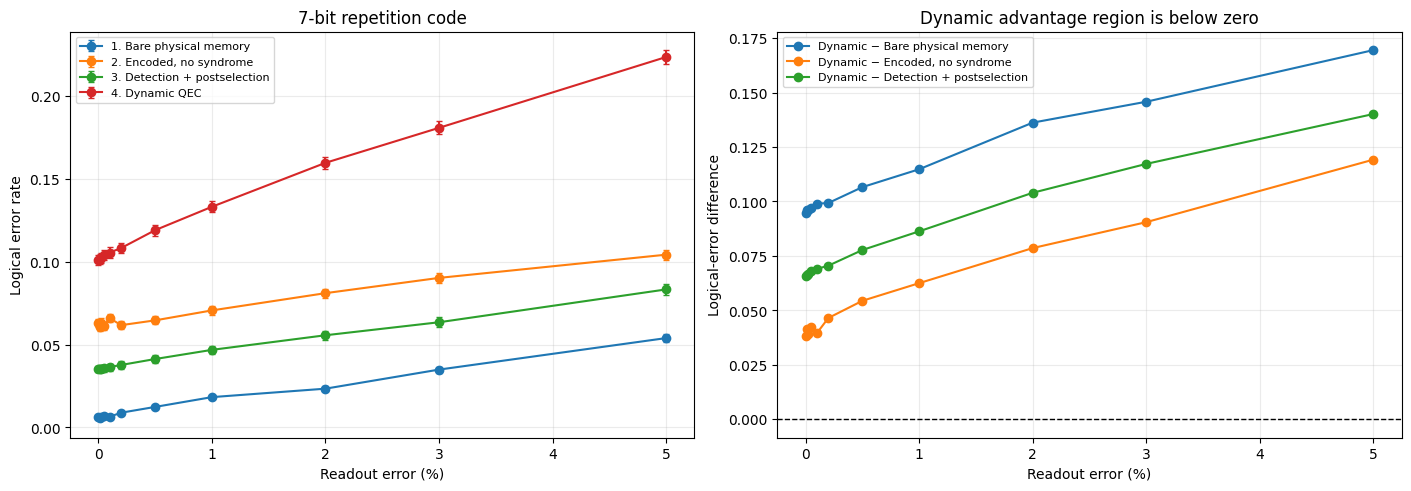

experiment,1. Bare physical memory,"2. Encoded, no syndrome",3. Detection + postselection,4. Dynamic QEC
readout_error,,,,
0.000000,0.6100%,6.2800%,3.5309%,10.1000%
0.000100,0.5700%,6.0300%,3.5331%,10.1800%
0.000200,0.6300%,6.3300%,3.5482%,10.2400%
0.000500,0.7000%,6.1400%,3.5781%,10.3800%
0.001000,0.6500%,6.5900%,3.6441%,10.5500%
0.002000,0.8900%,6.1700%,3.7688%,10.8200%
0.005000,1.2400%,6.4600%,4.1281%,11.9000%
0.010000,1.8300%,7.0600%,4.6805%,13.3100%
0.020000,2.3400%,8.1000%,5.5610%,15.9600%


In [183]:
READOUT_SWEEP_DISTANCE = 7
READOUT_SWEEP_SHOTS = 5_000
READOUT_ERROR_VALUES = np.array([
    0.0, 0.0001, 0.0002, 0.0005, 0.001,
    0.002, 0.005, 0.01, 0.02, 0.03, 0.05,
])


def sweep_readout_error(
    readout_values=READOUT_ERROR_VALUES,
    n=READOUT_SWEEP_DISTANCE,
    shots=READOUT_SWEEP_SHOTS,
    storage_rounds=STORAGE_ROUNDS,
    one_qubit_error=0.001,
    two_qubit_error=0.01,
    idle_error=0.001,
    reset_error=0.01,
    seed=SEED,
):
    records = []
    for index, readout_error in enumerate(readout_values):
        sweep_noise_model = make_noise_model(
            one_qubit_error=one_qubit_error,
            idle_error=idle_error,
            two_qubit_error=two_qubit_error,
            reset_error=reset_error,
            readout_error=float(readout_error),
        )
        sweep_simulator = AerSimulator(
            noise_model=sweep_noise_model,
            seed_simulator=seed + index,
        )
        table, _, _ = run_comparison(
            simulator=sweep_simulator,
            n=n,
            shots=shots,
            storage_rounds=storage_rounds,
            seed=seed + index,
        )
        for experiment, row in table.iterrows():
            records.append({
                'readout_error': float(readout_error),
                'experiment': experiment,
                'logical_error_rate': row['logical_error_rate'],
                'standard_error': row['standard_error'],
                'acceptance_rate': row['acceptance_rate'],
            })
    return pd.DataFrame(records)


def estimate_crossover(x, difference):
    """Linearly interpolate the first zero crossing; return None if absent."""
    order = np.argsort(x)
    x = np.asarray(x)[order]
    difference = np.asarray(difference)[order]
    for i in range(len(x) - 1):
        if difference[i] == 0:
            return float(x[i])
        if difference[i] * difference[i + 1] < 0:
            fraction = -difference[i] / (difference[i + 1] - difference[i])
            return float(x[i] + fraction * (x[i + 1] - x[i]))
    if difference[-1] == 0:
        return float(x[-1])
    return None


readout_sweep = sweep_readout_error()
readout_pivot = readout_sweep.pivot(
    index='readout_error',
    columns='experiment',
    values='logical_error_rate',
)
dynamic_errors = readout_pivot[EXPERIMENTS[3]]

print(f'{READOUT_SWEEP_DISTANCE}-bit dynamic-QEC readout crossover analysis:')
crossover_results = {}
for comparator in EXPERIMENTS[:3]:
    difference = dynamic_errors - readout_pivot[comparator]
    crossover = estimate_crossover(readout_pivot.index, difference)
    crossover_results[comparator] = crossover
    if crossover is None:
        status = 'no crossover in sweep range'
        if np.all(difference > 0):
            status += '; dynamic QEC is worse even at zero readout error'
        elif np.all(difference < 0):
            status += '; dynamic QEC is better throughout the range'
        print(f'  vs {comparator}: {status}')
    else:
        print(f'  vs {comparator}: crossover ≈ {crossover:.4%} readout error')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)
for experiment, group in readout_sweep.groupby('experiment', sort=False):
    axes[0].errorbar(
        100 * group['readout_error'],
        group['logical_error_rate'],
        yerr=group['standard_error'],
        marker='o',
        capsize=2,
        label=experiment,
    )
axes[0].set(
    xlabel='Readout error (%)',
    ylabel='Logical error rate',
    title=f'{READOUT_SWEEP_DISTANCE}-bit repetition code',
)
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

for comparator in EXPERIMENTS[:3]:
    advantage_gap = dynamic_errors - readout_pivot[comparator]
    axes[1].plot(
        100 * readout_pivot.index,
        advantage_gap,
        marker='o',
        label=f'Dynamic − {comparator.split(". ", 1)[1]}',
    )
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set(
    xlabel='Readout error (%)',
    ylabel='Logical-error difference',
    title='Dynamic advantage region is below zero',
)
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)
plt.show()

readout_pivot.style.format('{:.4%}')